In [47]:
import math
import random

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False

    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False

    return True

def compute_ks(n):
    ks = []
    max_k = int((2 * n) ** 0.5) + 2

    for k in range(2, max_k + 1):
        numerator = n - (k * (k - 1) // 2)

        if numerator > 0 and numerator % k == 0:
            ks.append(k)

    return ks

def analyze_number(n):
    ks = compute_ks(n)

    D = len(ks)
    W = sum(ks)

    return {
        "n": n,
        "prime": is_prime(n),
        "ks": ks,
        "D": D,
        "W": W
          }

def layered_sample(start, end, layers=5, per_layer=5):
    step = (end - start) // layers
    numbers = []

    for i in range(layers):
        a = start + i * step
        b = a + step
        numbers += random.sample(range(a, b), per_layer)

    return sorted(numbers)

def analyze_sample(numbers):
    results = []

    for n in numbers:
        results.append(analyze_number(n))

    return results

def display(results):
    print(f"{'n':<8} {'Prime':<6} {'D':<4} {'W':<6} ks")
    print("-" * 60)

    for r in results:
        print(f"{r['n']:<8} {str(r['prime']):<6} {r['D']:<4} {r['W']:<6} {r['ks']}")

if __name__ == "__main__":

    numbers = layered_sample(300000, 1000000, layers=5, per_layer=5)

    results = analyze_sample(numbers)

    display(results)

    def debug_cheker(results):
      if not r['prime'] and r['D']== 1:
        print("Issue,r")


n        Prime  D    W      ks
------------------------------------------------------------
328621   True   1    2      [2]
360313   False  7    863    [2, 31, 59, 62, 118, 197, 394]
370334   False  1    4      [4]
421975   False  5    92     [2, 5, 10, 25, 50]
438129   False  13   2421   [2, 3, 6, 9, 18, 27, 54, 81, 162, 243, 486, 601, 729]
485264   False  3    461    [13, 32, 416]
525243   False  3    11     [2, 3, 6]
527703   False  7    143    [2, 3, 6, 11, 22, 33, 66]
557058   False  7    2244   [3, 4, 12, 227, 409, 681, 908]
570436   False  1    8      [8]
639695   False  15   3173   [2, 5, 7, 10, 14, 35, 49, 70, 98, 245, 343, 373, 490, 686, 746]
666901   True   1    2      [2]
672297   False  7    383    [2, 3, 6, 31, 62, 93, 186]
672868   False  5    512    [7, 8, 49, 56, 392]
709639   False  3    23     [2, 7, 14]
756025   False  5    92     [2, 5, 10, 25, 50]
765304   False  3    640    [16, 271, 353]
765584   False  3    902    [32, 59, 811]
772069   False  3    143    [2, 4

In [45]:
import pandas as pd

# Extract D and W values from the results
d_values = [r['D'] for r in results]
w_values = [r['W'] for r in results]

# Create a pandas DataFrame
df_dw = pd.DataFrame({'D': d_values, 'W': w_values})

# Calculate the correlation between D and W
correlation_dw = df_dw['D'].corr(df_dw['W'])

print(f"The correlation between D (number of ways) and W (sum of lengths) is: {correlation_dw:.4f}")

The correlation between D (number of ways) and W (sum of lengths) is: 0.6902


In [60]:
def verify_signature(limit):
    errors = []

    for n in range(2, limit + 1):
        ks = compute_ks(n)
        D = len(ks)
        W = sum(ks)

        prime = is_prime(n)

        if n ==2:
          continue
        is_signature = (ks == [2] and D == 1 and W == 2)

        if prime and not is_signature:
            errors.append(("Prime failed", n, ks, D, W))

        if (not prime) and is_signature:
            errors.append(("Composite passed", n, ks, D, W))

    return errors

errors = verify_signature(100000)

if not errors:
    print("✅ All numbers match the signature property!")
else:
    print("❌ Errors found:")
    for e in errors[:10]:
        print(e)









✅ All numbers match the signature property!


In [68]:
import math



def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True



def compute_ks(n):
    ks = []
    max_k = int((2 * n) ** 0.5) + 2

    for k in range(2, max_k):
        numerator = n - (k * (k - 1) // 2)

        if numerator > 0 and numerator % k == 0:
            ks.append(k)

    return ks



def analyze_range(start, end):
    results = []

    for n in range(start, end + 1):
        ks = compute_ks(n)
        D = len(ks)
        W = sum(ks)

        results.append({
            'n': n,
            'prime': is_prime(n),
            'ks': ks,
            'D': D,
            'W': W
        })

    return results



def test_even_k_property(results):
    print("\n🔍 Checking D=3 cases...\n")

    found_issue = False

    for r in results:
        if r['D'] == 3:
            has_even = any(k % 2 == 0 for k in r['ks'])

            if not has_even:
                print("❗ Counterexample FOUND:")
                print(r)
                found_issue = True

    if not found_issue:
        print("✅ All D=3 numbers contain at least one even k")



def stats_even_k(results):
    total = 0
    with_even = 0

    for r in results:
        if r['D'] == 3:
            total += 1

            if any(k % 2 == 0 for k in r['ks']):
                with_even += 1

    print("\n📊 Statistics for D=3:\n")

    if total == 0:
        print("No D=3 numbers found")
        return

    percentage = (with_even / total) * 100

    print(f"Total D=3 numbers: {total}")
    print(f"Contain even k: {with_even}")
    print(f"Percentage: {percentage:.2f}%")


def show_examples(results, limit=10):
    print("\n📌 Examples (D=3 numbers):\n")

    count = 0

    for r in results:
        if r['D'] == 3:
            print(f"n={r['n']}, ks={r['ks']}, W={r['W']}")
            count += 1

            if count >= limit:
                break



if __name__ == "__main__":

    print("\n🚀 Running Analysis...\n")

    results = analyze_range(2, 1000)


    show_examples(results)


    test_even_k_property(results)


    stats_even_k(results)


def test_k2_k3_precise(results):
    total = 0
    with_3 = 0

    for r in results:
        if r['D'] == 3:
            total += 1


            if 2 not in r['ks']:
                print(":", r)

            # تحقق من وجود 3
            if 3 in r['ks']:
                with_3 += 1

    print("\n=== النتائج ===")
    print("Total D=3:", total)
    print("Contain k=3:", with_3)

    if total > 0:
        print("Ratio:", with_3 / total * 100)

if __name__ == "__main__":

    results = analyze_range(2, 1000)


    test_k2_k3_precise(results)




🚀 Running Analysis...


📌 Examples (D=3 numbers):

n=15, ks=[2, 3, 5], W=10
n=21, ks=[2, 3, 6], W=11
n=27, ks=[2, 3, 6], W=11
n=30, ks=[3, 4, 5], W=12
n=33, ks=[2, 3, 6], W=11
n=35, ks=[2, 5, 7], W=14
n=39, ks=[2, 3, 6], W=11
n=42, ks=[3, 4, 7], W=14
n=51, ks=[2, 3, 6], W=11
n=54, ks=[3, 4, 9], W=16

🔍 Checking D=3 cases...

❗ Counterexample FOUND:
{'n': 120, 'prime': False, 'ks': [3, 5, 15], 'D': 3, 'W': 23}
❗ Counterexample FOUND:
{'n': 240, 'prime': False, 'ks': [3, 5, 15], 'D': 3, 'W': 23}
❗ Counterexample FOUND:
{'n': 336, 'prime': False, 'ks': [3, 7, 21], 'D': 3, 'W': 31}
❗ Counterexample FOUND:
{'n': 432, 'prime': False, 'ks': [3, 9, 27], 'D': 3, 'W': 39}
❗ Counterexample FOUND:
{'n': 480, 'prime': False, 'ks': [3, 5, 15], 'D': 3, 'W': 23}
❗ Counterexample FOUND:
{'n': 672, 'prime': False, 'ks': [3, 7, 21], 'D': 3, 'W': 31}
❗ Counterexample FOUND:
{'n': 864, 'prime': False, 'ks': [3, 9, 27], 'D': 3, 'W': 39}
❗ Counterexample FOUND:
{'n': 960, 'prime': False, 'ks': [3, 5, 15], '

In [2]:
import math


def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True


def compute_ks(n):
    ks = []
    max_k = int((2 * n) ** 0.5) + 2

    for k in range(2, max_k):
        numerator = n - (k * (k - 1) // 2)

        if numerator >= 0 and numerator % k == 0:
            ks.append(k)

    return ks



def analyze_range(start, end):
    results = []

    for n in range(start, end + 1):
        ks = compute_ks(n)
        D = len(ks)
        W = sum(ks)
        prime_flag = is_prime(n)

        results.append({
            'n': n,
            'Prime': prime_flag,
            'ks': ks,
            'D': D,
            'W': W
        })

    return results



if __name__ == "__main__":

    # 👇 هنا تحددين النطاق
    results = analyze_range(2, 5000)


    print("\n--- اختبار W = 2 ---")

    bad_cases = []

    for r in results:
        if r['W'] == 2 and not r['Prime']:
            bad_cases.append(r)

    print("عدد الحالات المخالفة:", len(bad_cases))
    print("أمثلة:", bad_cases[:10])



    print("\n--- أمثلة أوليات ---")
    for r in results[:200]:
        if r['Prime']:
            print(r)

    print("\n--- أمثلة مركبات ---")
    for r in results[:200]:
        if not r['Prime']:
            print(r)


--- اختبار W = 2 ---
عدد الحالات المخالفة: 0
أمثلة: []

--- أمثلة أوليات ---
{'n': 2, 'Prime': True, 'ks': [], 'D': 0, 'W': 0}
{'n': 3, 'Prime': True, 'ks': [2, 3], 'D': 2, 'W': 5}
{'n': 5, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 7, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 11, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 13, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 17, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 19, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 23, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 29, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 31, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 37, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 41, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 43, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 47, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 53, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 59, 'Prime': True, 'ks': [2], 'D': 1, 'W': 2}
{'n': 61, 'Prime': True, 'ks': [2], 'D':

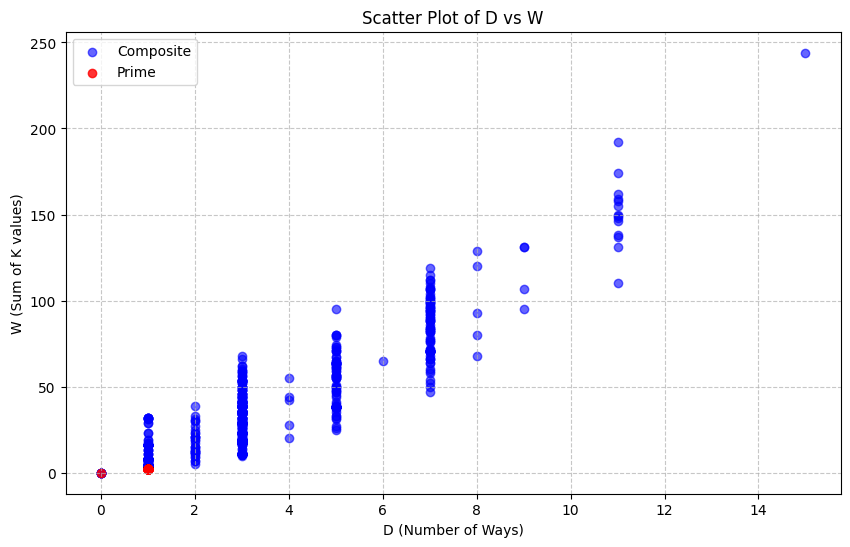

In [69]:
import matplotlib.pyplot as plt

def extract_for_plot(results):
    prime_D = []
    prime_W = []

    comp_D = []
    comp_W = []

    for r in results:
        if r["prime"]:
            prime_D.append(r["D"])
            prime_W.append(r["W"])
        else:
            comp_D.append(r["D"])
            comp_W.append(r["W"])

    return prime_D, prime_W, comp_D, comp_W

def plot_signature(results):
    prime_D, prime_W, comp_D, comp_W = extract_for_plot(results)

    plt.figure(figsize=(10, 6))

    # Plot composite numbers
    plt.scatter(comp_D, comp_W, color='blue', label='Composite', alpha=0.6)

    # Plot prime numbers
    plt.scatter(prime_D, prime_W, color='red', label='Prime', alpha=0.8)

    plt.xlabel("D (Number of Ways)")
    plt.ylabel("W (Sum of K values)")
    plt.title("Scatter Plot of D vs W")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Call the plotting function with the results
plot_signature(results)